In [7]:
import kagglehub
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
EPOCHS     = 5
BATCH      = 32
LR         = 1e-3
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# ── Dataset ──────────────────────────────────────────────────────────────────
path = kagglehub.dataset_download("samuelcortinhas/cats-and-dogs-image-classification")

tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

train_ds = datasets.ImageFolder(f"{path}/train", transform=tfm)
test_ds  = datasets.ImageFolder(f"{path}/test",  transform=tfm)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH)

print(f"Classes: {train_ds.classes} | Train: {len(train_ds)} | Test: {len(test_ds)}")

# ── Modelo (MobileNetV2 pré-treinado) ────────────────────────────────────────
model = models.mobilenet_v2(weights="DEFAULT")
model.classifier[1] = nn.Linear(model.last_channel, 2)   # 2 classes
model = model.to(DEVICE)

# ── Treino ───────────────────────────────────────────────────────────────────
opt      = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn  = nn.CrossEntropyLoss()

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = correct = 0
    for X, y in train_dl:
        X, y = X.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out  = model(X)
        loss = loss_fn(out, y)
        loss.backward()
        opt.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()

    acc = correct / len(train_ds) * 100
    print(f"Epoch {epoch}/{EPOCHS}  loss={total_loss/len(train_dl):.4f}  acc={acc:.1f}%")

# ── Avaliação ────────────────────────────────────────────────────────────────
model.eval()
correct = 0
with torch.no_grad():
    for X, y in test_dl:
        X, y = X.to(DEVICE), y.to(DEVICE)
        correct += (model(X).argmax(1) == y).sum().item()

print(f"\nTest accuracy: {correct / len(test_ds) * 100:.1f}%")

# ── Salvar modelo ─────────────────────────────────────────────────────────────
torch.save(model.state_dict(), "cats_dogs_model.pth")
print("Modelo salvo em cats_dogs_model.pth")

100%|██████████| 64.4M/64.4M [00:00<00:00, 185MB/s]

Extracting files...


Classes: ['cats', 'dogs'] | Train: 557 | Test: 140
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 103MB/s] 


Epoch 1/5  loss=0.3363  acc=83.8%
Epoch 2/5  loss=0.1069  acc=95.9%
Epoch 3/5  loss=0.0664  acc=98.6%
Epoch 4/5  loss=0.0602  acc=97.5%
Epoch 5/5  loss=0.0581  acc=97.5%

Test accuracy: 92.9%
Modelo salvo em cats_dogs_model.pth


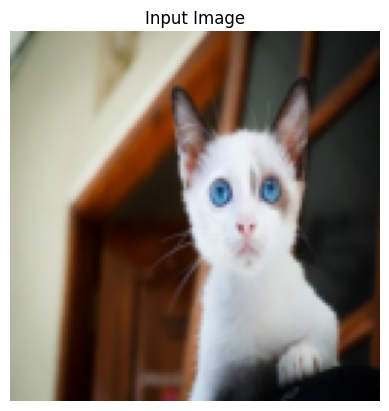

Predição: cats  (81.2%)
  cats: 81.2%  |  dogs: 18.8%


In [8]:
model.load_state_dict(torch.load("cats_dogs_model.pth", map_location=DEVICE))
model.eval()

img = tfm(Image.open("animal3.jpg").convert("RGB")).unsqueeze(0).to(DEVICE)

# Denormalize the image for display
img_display = img.squeeze(0).cpu().numpy()
img_display = img_display * 0.5 + 0.5 # Undo normalization
img_display = np.transpose(img_display, (1, 2, 0)) # Permute from (C, H, W) to (H, W, C)

plt.imshow(img_display)
plt.axis('off') # Hide axes
plt.title('Input Image')
plt.show()


with torch.no_grad():
    probs = torch.softmax(model(img), dim=1)[0]

classes = train_ds.classes  # ['cats', 'dogs']
print(f"Predição: {classes[probs.argmax()]}  ({probs.max()*100:.1f}%)")
print(f"  cats: {probs[0]*100:.1f}%  |  dogs: {probs[1]*100:.1f}%")